## Project: Ecommerce Sales Analysis

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("ecommerce_dataset - ecommerce_dataset.csv")
df

,order_id,product,category,price,quantity,payment_method,date,total,Month,Discount,City Code,Order Priority Code,Latitude,Longtitude
0,1,Watch,Electronics,12652.30,4,Easypaisa,01/01/2023,50609.20,January,0.0,1.0,2.0,1.0,0.0
1,2,Bag,Fashion,20053.64,2,Credit Card,02/01/2023,40107.28,January,0.1,1.0,2.0,1.0,0.0
2,3,Shoes,Fashion,13274.17,2,JazzCash,03/01/2023,26548.34,January,0.1,1.0,2.0,1.0,0.0
3,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0,1.0,0.0
4,5,Bag,Accessories,23165.07,1,Debit Card,05/01/2023,23165.07,January,0.0,1.0,NaN,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0,1.0,0.0
502,18,Headphones,Electronics,14085.56,2,Debit Card,18/01/2023,28171.12,January,0.0,1.0,2.0,1.0,0.0
503,19,Laptop,Accessories,53657.14,4,Debit Card,19/01/2023,214628.56,January,0.1,1.0,2.0,1.0,0.0
504,20,Watch,Fashion,74385.39,4,Credit Card,20/01/2023,297541.56,January,0.0,1.0,2.0,1.0,0.0


In [3]:
df.dtypes   # types of data

order_id                 int64
product                 object
category                object
price                  float64
quantity                 int64
payment_method          object
date                    object
total                  float64
Month                   object
Discount               float64
City Code              float64
Order Priority Code    float64
Latitude               float64
Longtitude             float64
dtype: object

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   order_id             506 non-null    int64  
 1   product              506 non-null    object 
 2   category             506 non-null    object 
 3   price                506 non-null    float64
 4   quantity             506 non-null    int64  
 5   payment_method       506 non-null    object 
 6   date                 506 non-null    object 
 7   total                506 non-null    float64
 8   Month                506 non-null    object 
 9   Discount             506 non-null    float64
 10  City Code            491 non-null    float64
 11  Order Priority Code  487 non-null    float64
 12  Latitude             506 non-null    float64
 13  Longtitude           506 non-null    float64
dtypes: float64(7), int64(2), object(5)
memory usage: 55.5+ KB


In [5]:
df.drop(columns=["Latitude", "Longtitude"], inplace=True)  # Drop irrelevant columns (Latitude, Longitude)

In [6]:
df.head()

,order_id,product,category,price,quantity,payment_method,date,total,Month,Discount,City Code,Order Priority Code
0,1,Watch,Electronics,12652.30,4,Easypaisa,01/01/2023,50609.20,January,0.0,1.0,2.0
1,2,Bag,Fashion,20053.64,2,Credit Card,02/01/2023,40107.28,January,0.1,1.0,2.0
2,3,Shoes,Fashion,13274.17,2,JazzCash,03/01/2023,26548.34,January,0.1,1.0,2.0
3,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0
4,5,Bag,Accessories,23165.07,1,Debit Card,05/01/2023,23165.07,January,0.0,1.0,NaN


In [7]:
df.rename(columns={
    "City Code": "City",
    "Order Priority Code": "Order Priority"
}, inplace=True)                                # Rename columns City Code to City & Order Priority Code to Order Priority

In [8]:
df.columns

Index(['order_id', 'product', 'category', 'price', 'quantity',
       'payment_method', 'date', 'total', 'Month', 'Discount', 'City',
       'Order Priority'],
      dtype='object')

In [9]:
df.duplicated().sum()   # Check duplicate rows

np.int64(6)

In [10]:
df[df.duplicated()]

,order_id,product,category,price,quantity,payment_method,date,total,Month,Discount,City,Order Priority
500,3,Shoes,Fashion,13274.17,2,JazzCash,03/01/2023,26548.34,January,0.1,1.0,2.0
501,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0
502,18,Headphones,Electronics,14085.56,2,Debit Card,18/01/2023,28171.12,January,0.0,1.0,2.0
503,19,Laptop,Accessories,53657.14,4,Debit Card,19/01/2023,214628.56,January,0.1,1.0,2.0
504,20,Watch,Fashion,74385.39,4,Credit Card,20/01/2023,297541.56,January,0.0,1.0,2.0
505,21,Bag,Electronics,44762.65,4,COD,21/01/2023,179050.60,January,0.0,1.0,2.0


In [11]:
df.drop_duplicates(inplace=True)  # Drop duplicate records

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.isnull().sum()   # Check missing and null values

order_id           0
product            0
category           0
price              0
quantity           0
payment_method     0
date               0
total              0
Month              0
Discount           0
City              15
Order Priority    19
dtype: int64

In [14]:
df["total"].median()    # Fill missing sales value by their median

78100.345

In [15]:
df["total"].fillna(df["total"].median(), inplace=True)

In [16]:
df["total"].isnull().sum()

np.int64(0)

In [17]:
top_products = (
    df.groupby("product")["total"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

top_products

product
Headphones    9414259.95
Watch         9295181.97
Mobile        8478520.28
Shoes         8304435.17
Laptop        7908062.14
Name: total, dtype: float64

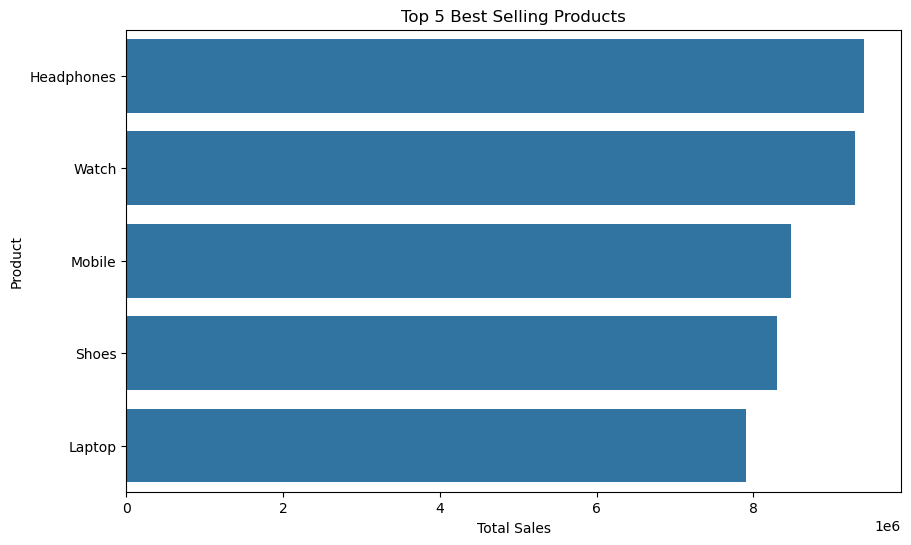

In [18]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 5 Best Selling Products")
plt.xlabel("Total Sales")
plt.ylabel("Product")

plt.show()      # Top 5 Best Selling Products

In [19]:
payment_counts = df["payment_method"].value_counts()

payment_counts

payment_method
JazzCash       112
Credit Card    107
Easypaisa      105
COD             97
Debit Card      79
Name: count, dtype: int64

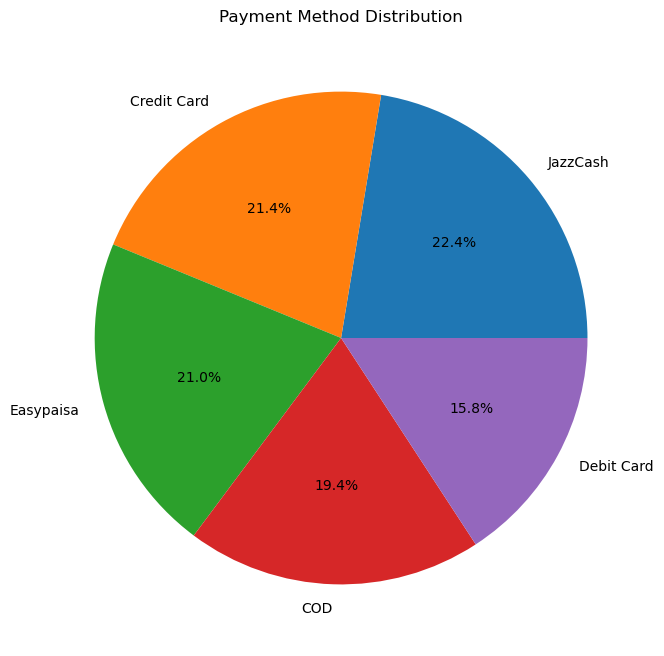

In [20]:
plt.figure(figsize=(8, 8))

plt.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct="%1.1f%%"
)

plt.title("Payment Method Distribution")

plt.show()      # Payment Method Distribution

In [21]:
monthly_sales = df.groupby("Month")["total"].sum()
monthly_sales

Month
April        6275753.74
August       2557288.54
December     3952563.75
February     5545040.22
January      6238414.59
July         2688475.62
June         2860920.11
March        6711119.66
May          5909845.92
November     2805153.37
October      3139444.82
September    2515916.08
Name: total, dtype: float64

In [22]:
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"
]

monthly_sales = (
    df.groupby("Month")["total"]
    .sum()
    .reindex(month_order)
)

monthly_sales

Month
January      6238414.59
February     5545040.22
March        6711119.66
April        6275753.74
May          5909845.92
June         2860920.11
July         2688475.62
August       2557288.54
September    2515916.08
October      3139444.82
November     2805153.37
December     3952563.75
Name: total, dtype: float64

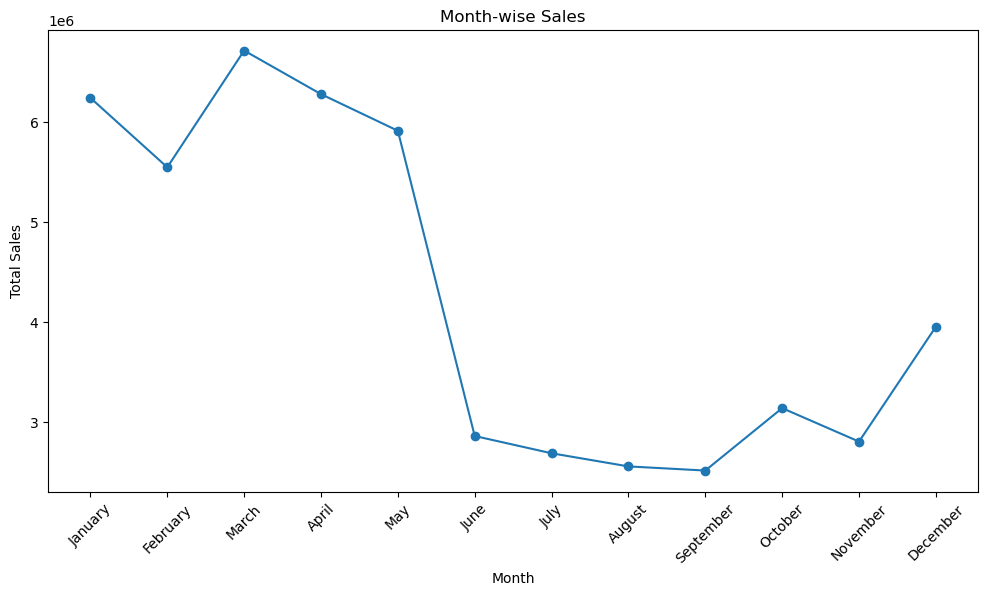

In [23]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Month-wise Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()       # Month-wise Sales

In [24]:
city_mapping = {
    1: "Karachi",
    2: "Lahore",
    3: "Islamabad",
    4: "Faisalabad",
    5: "Quetta",
    6: "Peshawar"
}

df["City"] = df["City"].map(city_mapping)

In [25]:
df["City"].value_counts()

City
Lahore        140
Quetta         97
Islamabad      77
Peshawar       71
Faisalabad     52
Karachi        48
Name: count, dtype: int64

In [26]:
city_sales = (
    df.groupby("City")["total"]
    .sum()
    .sort_values(ascending=True)
)

city_sales

City
Karachi        5060916.14
Peshawar       6194016.19
Faisalabad     6318998.97
Islamabad      8028811.58
Quetta         9488620.43
Lahore        14665005.16
Name: total, dtype: float64

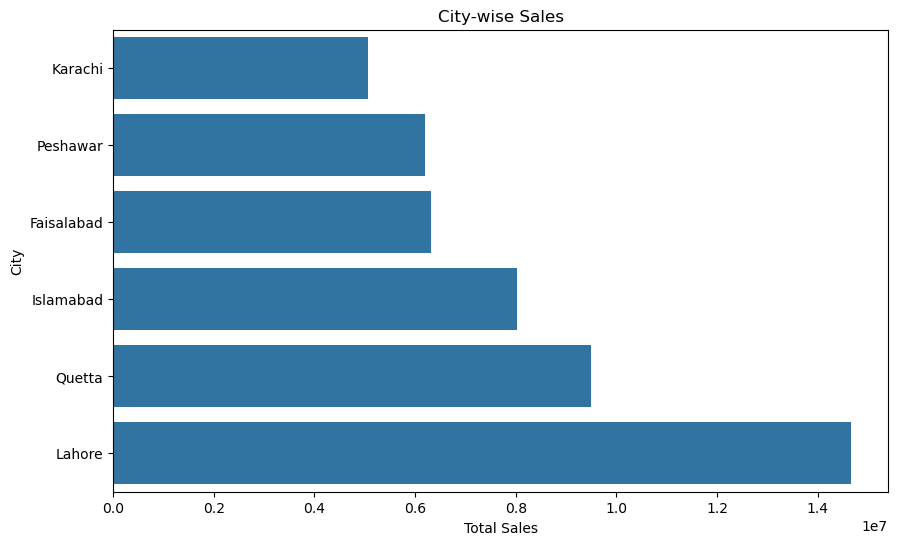

In [27]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=city_sales.values,
    y=city_sales.index
)

plt.title("City-wise Sales")
plt.xlabel("Total Sales")
plt.ylabel("City")

plt.show()      # Show City wise sales

In [28]:
monthly_category_sales = df.pivot_table(
    index="Month",
    columns="category",
    values="total",
    aggfunc="sum"
)

monthly_category_sales = monthly_category_sales.reindex(month_order)

monthly_category_sales

category,Accessories,Electronics,Fashion
Month,,,
January,2745729.82,1855039.15,1637645.62
February,1178881.69,1929360.80,2436797.73
March,2749630.71,2457415.74,1504073.21
April,2387980.38,2265079.20,1622694.16
May,1240740.21,2352232.89,2316872.82
June,1421673.13,657353.10,781893.88
July,961408.72,1218489.97,508576.93
August,521529.94,881950.11,1153808.49
September,849152.91,952931.97,713831.20


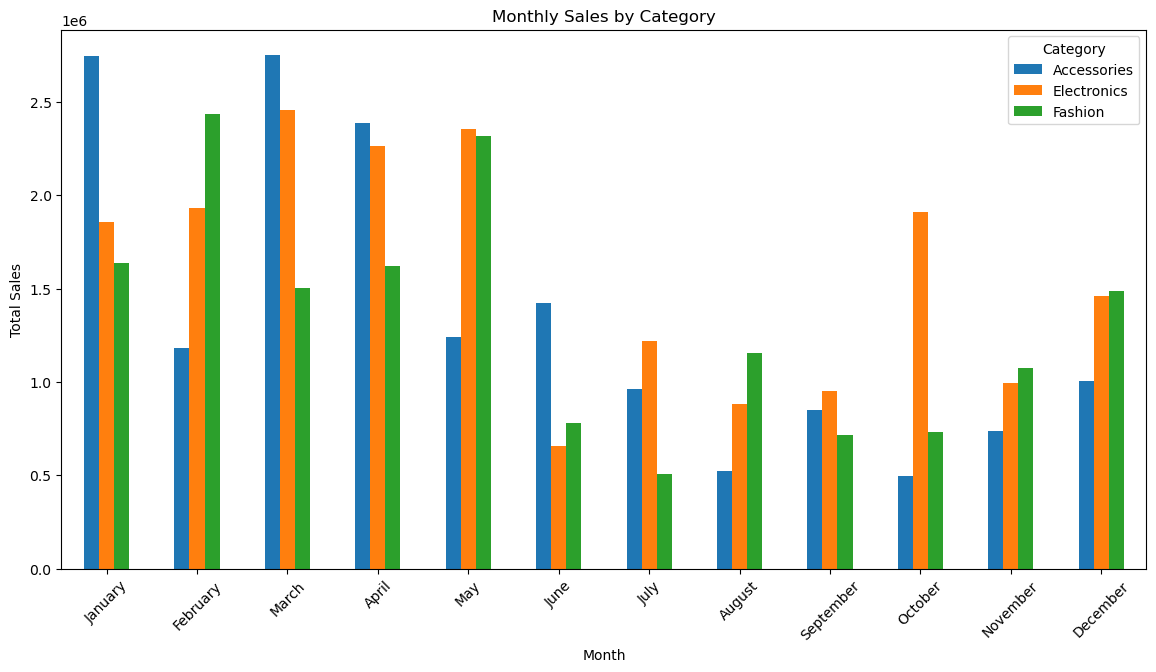

In [29]:
monthly_category_sales.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Monthly Sales by Category")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.legend(title="Category")

plt.show()     # Show monthly Sales by Category